In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def get_stock_data(ticker, period="1y"):
    stock = yf.download(ticker, period=period, multi_level_index= False)
    return stock
    """
    Download historical stock data.
    ticker = stock symbol e.g "AAPL"
    period = how far back e.g "1y", "6mo", "2y"
    """
if __name__ =="__main__":
    data = get_stock_data("AAPL")
    print(f"\nFirst 5 rows:\n {data.head(5)}")
    print(f"\nLast 5 rows:\n {data.tail(5)})")
    print("\nShape:", data.shape)
    print("\nColumns:", data.columns.tolist())


[*********************100%***********************]  1 of 1 completed


First 5 rows:
                  Close        High         Low        Open     Volume
Date                                                                 
2025-04-11  197.290115  198.674083  185.252584  185.292419   87435900
2025-04-14  201.641159  212.015939  200.287060  210.522448  101352900
2025-04-15  201.262817  202.626867  198.932975  200.984034   51343900
2025-04-16  193.426956  199.829045  191.535192  197.499204   59732400
2025-04-17  196.125198  197.967176  193.576310  196.344245   52164700

Last 5 rows:
                  Close        High         Low        Open    Volume
Date                                                                
2026-04-06  258.859985  262.160004  256.459991  256.510010  29329900
2026-04-07  253.500000  256.200012  245.699997  256.160004  62148000
2026-04-08  258.899994  259.750000  256.529999  258.450012  41032800
2026-04-09  260.489990  261.119995  256.070007  259.000000  28121600
2026-04-10  260.480011  262.190002  259.019989  259.980011  31259

In [3]:
Close = data["Close"].squeeze() #Extract closing price
data["Daily_return"] = Close.pct_change().fillna(0) #Daily returnn
data["Cumulative_return"] = (1 + data["Daily_return"]).cumprod() #Cumulative return
# Moving Averages
data["MA_50"] = Close.rolling(window=50).mean()
data["MA_200"] = Close.rolling(window=200).mean()

#Volatility (annualized)
daily_vol = data["Daily_return"].std()
annual_vol = daily_vol * np.sqrt(252)

# Sharpe ratio
avg_daily_return = data["Daily_return"].mean()
sharpe_ratio = (avg_daily_return / daily_vol) * np.sqrt(252)

print(f"Financial summary for AAPL\n")
print(f"Start Price: ${float(Close.iloc[0]):.2f}")
print(f"End Price: ${float(Close.iloc[-1]):.2f}")
print(f"Cumulative_return: {float(data['Cumulative_return'].iloc[-1]) * 100:.2f}%")
print(f"Annualized vol: {float(annual_vol) * 100:.2f}%")
print(f"Sharpe ratio: {float(sharpe_ratio):.2f}")


Financial summary for AAPL

Start Price: $197.29
End Price: $260.48
Cumulative_return: 132.03%
Annualized vol: 23.74%
Sharpe ratio: 1.30


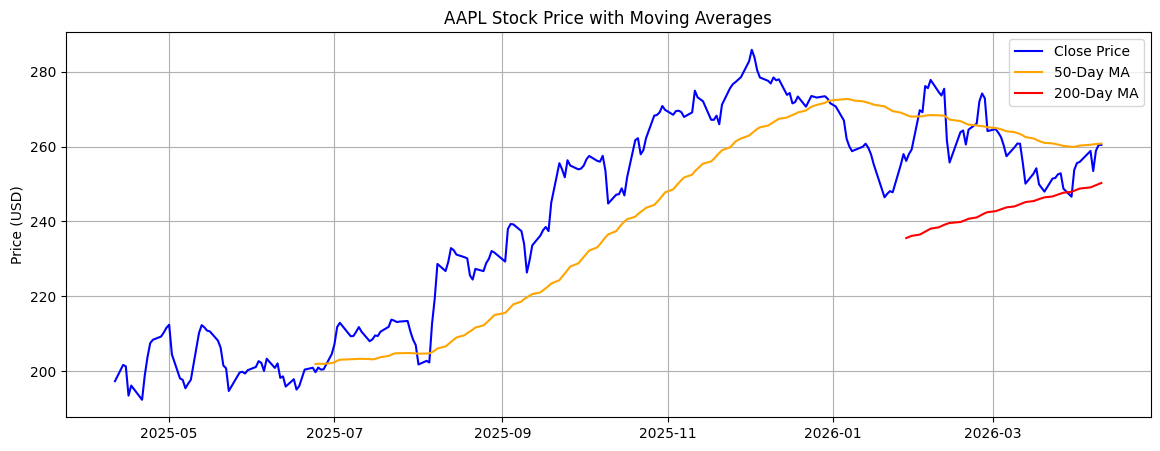

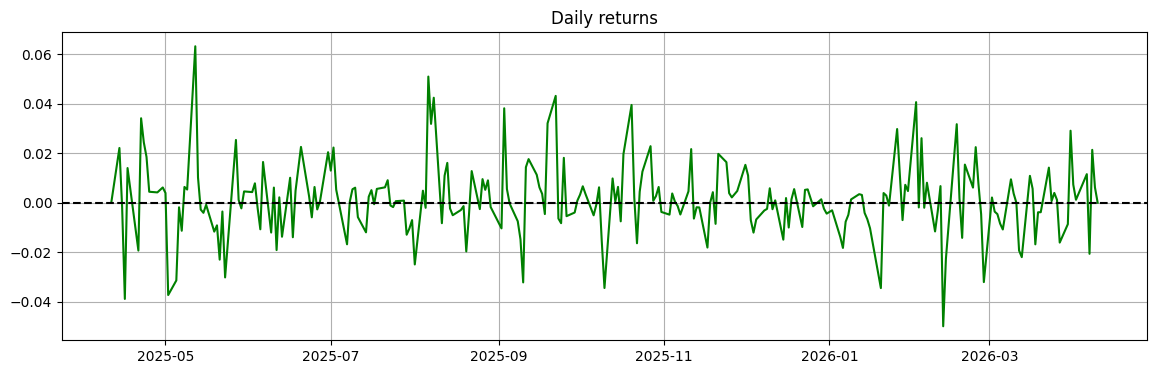

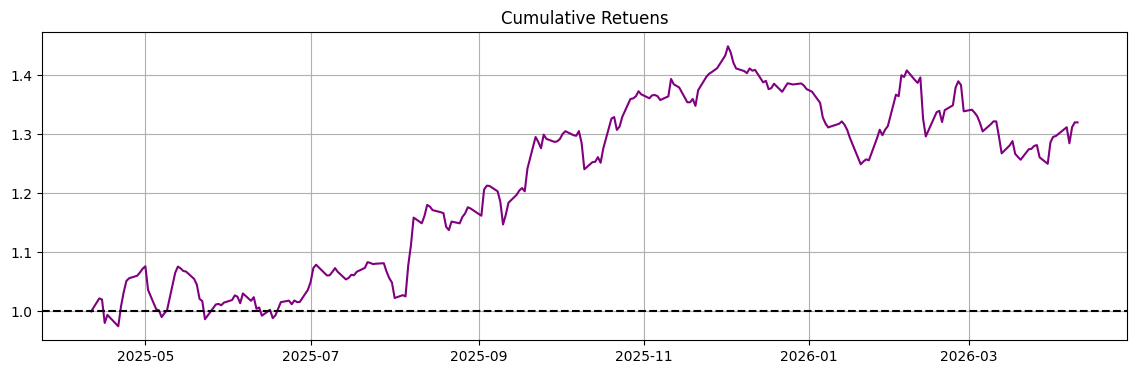

In [6]:
# Chart 1 - Price with Moving Averages
plt.figure(figsize=(14,5))
plt.plot(data["Close"], label="Close Price", color="blue")
plt.plot(data["MA_50"], label="50-Day MA", color="orange")
plt.plot(data["MA_200"], label="200-Day MA", color="red")
plt.title("AAPL Stock Price with Moving Averages")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Chart 2 - Daily returns
plt.figure(figsize=(14, 4))
plt.plot(data["Daily_return"], color="green")
plt.axhline(y=0, color="black", linestyle="--")
plt.title("Daily returns")
plt.grid(True)
plt.show()

# Chart 3 - Cumulative returns
plt.figure(figsize=(14,4))
plt.plot(data["Cumulative_return"], color="purple")
plt.axhline(y=1, color="black", linestyle="--")
plt.title("Cumulative Retuens")
plt.grid(True)
plt.show()


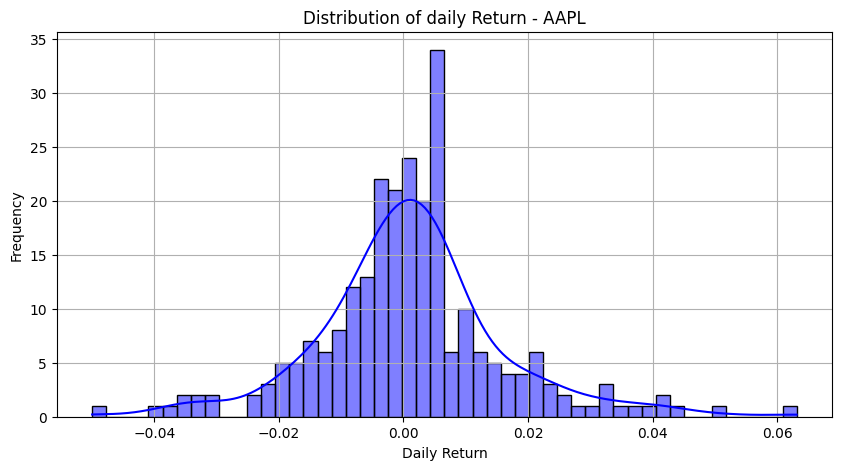

[*********************100%***********************]  5 of 5 completed


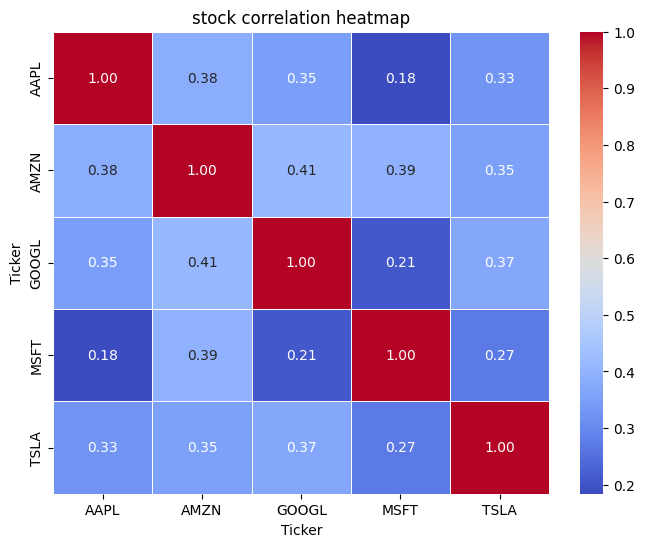

In [10]:
# Chart 1 - Distribution of Daily Returns
plt.figure(figsize=(10,5))
sns.histplot(data["Daily_return"].dropna(), bins=50, kde=True, color="blue")
plt.title("Distribution of daily Return - AAPL")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Chart 2 - Correlation Heatmap (Multiple Stocks)
tickers = ["AAPL", "TSLA", "MSFT", "GOOGL", "AMZN"]
multi_data = yf.download(tickers, period="1y")["Close"]
returns_all = multi_data.pct_change().dropna()
correlation = returns_all.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("stock correlation heatmap")
plt.show()
